Imports and load cleaned data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers

plt.rcParams['figure.figsize'] = (14, 5)

adj_close = pd.read_csv('../data/processed/adj_close_combined.csv', index_col='Date', parse_dates=True)

Chronological train/test split

In [6]:
tsla = adj_close["TSLA"]
tsla.head()

Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: TSLA, dtype: float64

In [7]:
split_date = "2025-01-01"

train = tsla[tsla.index < split_date]
test = tsla[tsla.index >= split_date]

print(
    "Train:",
    train.index.min(),
    "->",
    train.index.max(),
    f"({len(train)} observations)"
)

print(
    "Test:",
    test.index.min(),
    "->",
    test.index.max(),
    f"({len(test)} observations)"
)

Train: 2015-01-02 00:00:00 -> 2024-12-31 00:00:00 (2608 observations)
Test: 2025-01-01 00:00:00 -> 2026-06-29 00:00:00 (389 observations)


ARIMA model with auto_arima

In [8]:
arima_model = pm.auto_arima(
    train,
    seasonal=False,        # stock prices rarely show stable seasonality
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16858.977, Time=7.26 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.38 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.51 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.68 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.32 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=16878.233, Time=1.65 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16878.294, Time=2.90 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16857.881, Time=3.25 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16878.243, Time=1.66 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=16859.736, Time=6.68 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=16862.636, Time=8.61 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=16857.948, Time=5.55 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16874.277, Time=2.12 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=16858.879, Time=6.18 sec
 ARIMA(3,1,2)(0,0,0

Forecast the test period and evaluate

In [9]:
n_periods = len(test)
arima_forecast, arima_ci = arima_model.predict(n_periods=n_periods, return_conf_int=True)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(y_true))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

arima_metrics = evaluate(test.values, arima_forecast)
print(arima_metrics)

{'MAE': 54.46831282235665, 'RMSE': 70.82092723514802, 'MAPE': 17.24986574680942}


Plot ARIMA forecast vs actual

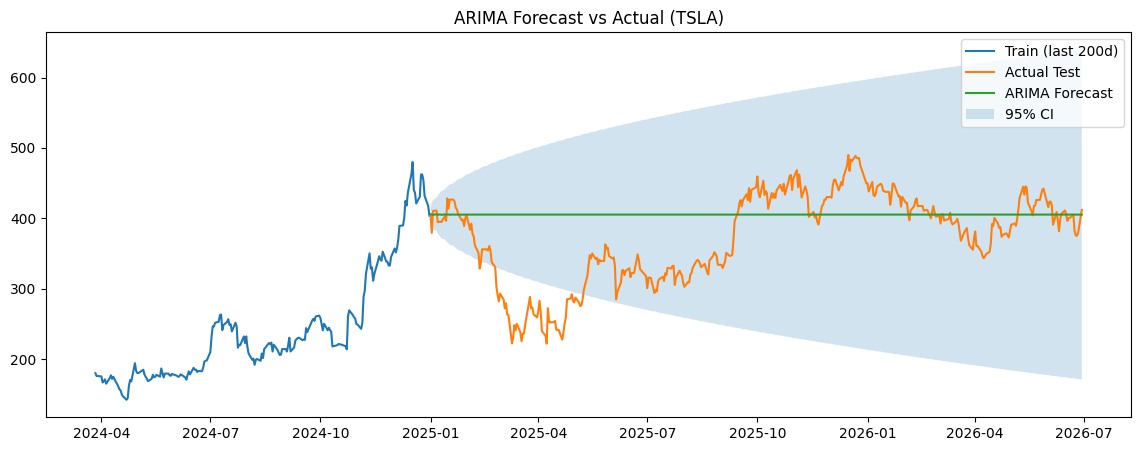

In [10]:
plt.plot(train.index[-200:], train.values[-200:], label='Train (last 200d)')
plt.plot(test.index, test.values, label='Actual Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.fill_between(test.index, arima_ci[:,0], arima_ci[:,1], alpha=0.2, label='95% CI')
plt.title('ARIMA Forecast vs Actual (TSLA)')
plt.legend()
plt.savefig('../data/processed/arima_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

LSTM: prepare sequences

In [11]:
WINDOW = 60  # use last 60 days to predict next day

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

def make_sequences(values, window):
    X, y = [], []
    for i in range(window, len(values)):
        X.append(values[i-window:i, 0])
        y.append(values[i, 0])
    return np.array(X).reshape(-1, window, 1), np.array(y)

X_train, y_train = make_sequences(train_scaled, WINDOW)
print(X_train.shape, y_train.shape)

(2548, 60, 1) (2548,)


 Build and train the LSTM

In [12]:
model = keras.Sequential([
    layers.Input(shape=(WINDOW, 1)),
    layers.LSTM(50, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(50, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(25, activation='relu'),
    layers.Dense(1),
])
model.compile(optimizer='adam', loss='mean_squared_error')

early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=25, batch_size=32, callbacks=[early_stop], verbose=1)

Epoch 1/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - loss: 0.0072
Epoch 2/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0020
Epoch 3/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0016
Epoch 4/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0014
Epoch 5/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0014
Epoch 6/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0013
Epoch 7/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0012
Epoch 8/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0010
Epoch 9/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 9.8851e-04
Epoch 10/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0012
Epoch 11/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 9.1793e-04
Epoch 12/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 9.2166e-04
Epoch 13/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 7.9284e-04
Epoch 14/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 8.7713e-04
Epoch 15/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/ste

Forecast the test period with LSTM

In [13]:
inputs = tsla[len(tsla) - len(test) - WINDOW:].values.reshape(-1, 1)
inputs_scaled = scaler.transform(inputs)

X_test, _ = make_sequences(inputs_scaled, WINDOW)
lstm_preds_scaled = model.predict(X_test, verbose=0)
lstm_forecast = scaler.inverse_transform(lstm_preds_scaled).flatten()

lstm_metrics = evaluate(test.values, lstm_forecast)
print(lstm_metrics)

{'MAE': 24.08758215426174, 'RMSE': 27.877852235473807, 'MAPE': 6.294459278733901}


Plot LSTM forecast vs actual

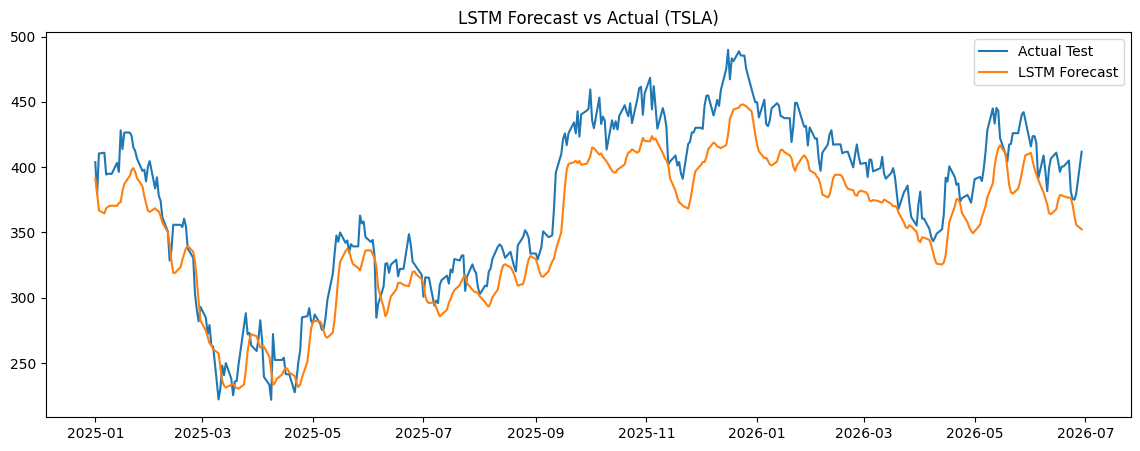

In [14]:
plt.plot(test.index, test.values, label='Actual Test')
plt.plot(test.index, lstm_forecast, label='LSTM Forecast')
plt.title('LSTM Forecast vs Actual (TSLA)')
plt.legend()
plt.savefig('../data/processed/lstm_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

Compare both models

In [15]:
comparison = pd.DataFrame({'ARIMA': arima_metrics, 'LSTM': lstm_metrics}).T
comparison

,MAE,RMSE,MAPE
ARIMA,54.468313,70.820927,17.249866
LSTM,24.087582,27.877852,6.294459
